# 1.3 — Wine Data EDA on the **original** white-wine dataset (baseline)

This notebook performs EDA on the original Wine Dataset (`wine-quality/original.csv`, the white-wine data).

**Note:** `original.csv` contains **many duplicate rows**: 937 of its 4,898 rows (about 19%) are exact repeats of another row.
Duplicates over-weight some wines and bias statistics, so this notebook first removes them, saves the result as
`wine-quality/original_no_duplicates.csv`, and runs the whole EDA on that deduplicated dataset.

After reviewing this notebook, run the next one: `1.4_WineQuality_DataCleaning.ipynb` that shows different cleaning strategies for a perturbed dataset (artificially introduced naturally occurring defects in raw datasets) derived from the original wine quality data.
`original_no_duplicates.csv` generated in this notebook will be used as the **baseline** for the next notebook, so run this notebook before 1.4.


This notebook was developed with support of Anthropic's Claude Opus 5.5

# Setup

In [ ]:
# Loading the libraries (EDA only)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Setting up tweaks for the visualization
sns.set(style="whitegrid")

# Loading the data

In [ ]:
# Load the original dataset (path relative to this notebook's folder)
ORIGINAL_PATH = "wine-quality/original.csv"
NO_DUPLICATES_PATH = "wine-quality/original_no_duplicates.csv"

original_df = pd.read_csv(ORIGINAL_PATH)
print(f"Loaded: {ORIGINAL_PATH}  ({original_df.shape[0]:,} rows, {original_df.shape[1]} columns)")
original_df.head()

Loaded: wine-quality/original.csv  (4,898 rows, 12 columns)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Removing duplicate rows

`original.csv` contains many exact duplicate rows. Before exploring the data we count them, drop them, and save the
deduplicated dataset. The rest of the notebook works on `raw_wine_df`, which from here on is the **deduplicated** data.

In [ ]:
# Count exact duplicate rows in the original file
n_dup_original = original_df.duplicated().sum()
print(f"Duplicated rows in original.csv: {n_dup_original:,} ({100 * n_dup_original / len(original_df):.2f}%)")

# Remove them (the first occurrence of each row is kept) and save the baseline for notebook 1.4
raw_wine_df = original_df.drop_duplicates().reset_index(drop=True)
raw_wine_df.to_csv(NO_DUPLICATES_PATH, index=False)

print(f"Rows after removing duplicates: {len(raw_wine_df):,}")
print(f"Saved: {NO_DUPLICATES_PATH}")

Duplicated rows in original.csv: 937 (19.13%)
Rows after removing duplicates: 3,961
Saved: wine-quality/original_no_duplicates.csv


In [ ]:
raw_wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3961 entries, 0 to 3960
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         3961 non-null   float64
 1   volatile acidity      3961 non-null   float64
 2   citric acid           3961 non-null   float64
 3   residual sugar        3961 non-null   float64
 4   chlorides             3961 non-null   float64
 5   free sulfur dioxide   3961 non-null   float64
 6   total sulfur dioxide  3961 non-null   float64
 7   density               3961 non-null   float64
 8   pH                    3961 non-null   float64
 9   sulphates             3961 non-null   float64
 10  alcohol               3961 non-null   float64
 11  quality               3961 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 371.5 KB


In [ ]:
raw_wine_df.head().T

,0,1,2,3,4
fixed acidity,7.000,6.300,8.1000,7.2000,6.2000
volatile acidity,0.270,0.300,0.2800,0.2300,0.3200
citric acid,0.360,0.340,0.4000,0.3200,0.1600
residual sugar,20.700,1.600,6.9000,8.5000,7.0000
chlorides,0.045,0.049,0.0500,0.0580,0.0450
free sulfur dioxide,45.000,14.000,30.0000,47.0000,30.0000
total sulfur dioxide,170.000,132.000,97.0000,186.0000,136.0000
density,1.001,0.994,0.9951,0.9956,0.9949
pH,3.000,3.300,3.2600,3.1900,3.1800
sulphates,0.450,0.490,0.4400,0.4000,0.4700


In [ ]:
raw_wine_df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,3961.0,6.839346,0.866860,3.80000,6.30000,6.8000,7.30000,14.20000
volatile acidity,3961.0,0.280538,0.103437,0.08000,0.21000,0.2600,0.33000,1.10000
citric acid,3961.0,0.334332,0.122446,0.00000,0.27000,0.3200,0.39000,1.66000
residual sugar,3961.0,5.914819,4.861646,0.60000,1.60000,4.7000,8.90000,65.80000
chlorides,3961.0,0.045905,0.023103,0.00900,0.03500,0.0420,0.05000,0.34600
free sulfur dioxide,3961.0,34.889169,17.210021,2.00000,23.00000,33.0000,45.00000,289.00000
total sulfur dioxide,3961.0,137.193512,43.129065,9.00000,106.00000,133.0000,166.00000,440.00000
density,3961.0,0.993790,0.002905,0.98711,0.99162,0.9935,0.99571,1.03898
pH,3961.0,3.195458,0.151546,2.72000,3.09000,3.1800,3.29000,3.82000
sulphates,3961.0,0.490351,0.113523,0.22000,0.41000,0.4800,0.55000,1.08000


# Exploratory Data Analysis (EDA)

The goal of this section is to understand the dataset before applying any preprocessing or training a model.

We will review:

1. Dataset structure and data quality.
2. Target variable (`quality`) distribution.
3. Univariate analysis of numerical variables.
4. Skewness and potential outliers.
5. Bivariate relationships between predictors and wine quality.
6. Relationships among predictors.
7. Correlation analysis using Pearson and Spearman coefficients.
8. Multivariate profiles by wine quality.


## Dataset structure and data quality

Before analyzing distributions, verify the shape, data types, missing values, duplicated observations, and the number of unique values per column.


In [ ]:
# Dataset dimensions
print(f"Rows: {raw_wine_df.shape[0]:,}")
print(f"Columns: {raw_wine_df.shape[1]}")

# Compact data-quality summary
data_quality = pd.DataFrame({
    "dtype": raw_wine_df.dtypes,
    "missing": raw_wine_df.isna().sum(),
    "missing_pct": raw_wine_df.isna().mean() * 100,
    "n_unique": raw_wine_df.nunique()
})

data_quality.sort_values("missing_pct", ascending=False)


Rows: 3,961
Columns: 12


,dtype,missing,missing_pct,n_unique
fixed acidity,float64,0,0.0,68
volatile acidity,float64,0,0.0,125
citric acid,float64,0,0.0,87
residual sugar,float64,0,0.0,310
chlorides,float64,0,0.0,160
free sulfur dioxide,float64,0,0.0,132
total sulfur dioxide,float64,0,0.0,251
density,float64,0,0.0,890
pH,float64,0,0.0,103
sulphates,float64,0,0.0,79


In [ ]:
# Duplicate observations (expected to be 0: duplicates were removed right after loading)
n_duplicates = raw_wine_df.duplicated().sum()
duplicate_pct = 100 * n_duplicates / len(raw_wine_df)

print(f"Duplicated rows: {n_duplicates:,}")
print(f"Percentage of duplicated rows: {duplicate_pct:.2f}%")


Duplicated rows: 0
Percentage of duplicated rows: 0.00%


## Target variable analysis: `quality`

Because `quality` is the response variable, inspect both its absolute frequency and relative frequency. This helps identify class imbalance before any train/test split is performed.


In [ ]:
quality_summary = pd.DataFrame({
    "count": raw_wine_df["quality"].value_counts().sort_index(),
    "percentage": raw_wine_df["quality"].value_counts(normalize=True).sort_index() * 100
})

quality_summary


,count,percentage
quality,,
3,20,0.504923
4,153,3.862661
5,1175,29.664226
6,1788,45.140116
7,689,17.394597
8,131,3.307246
9,5,0.126231


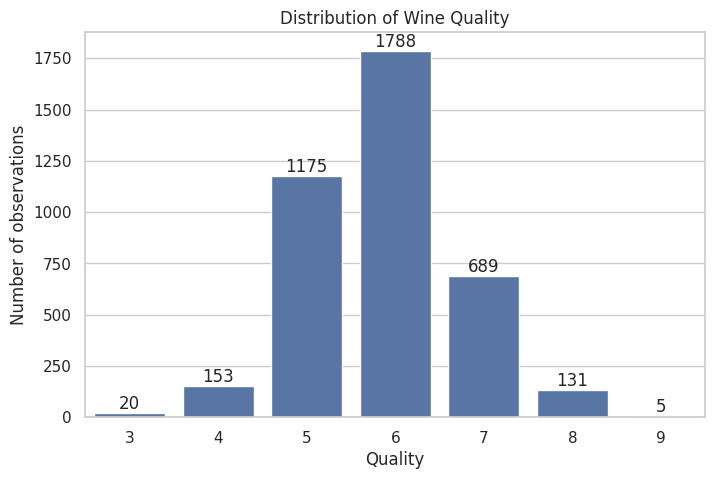

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=raw_wine_df, x="quality")

plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Number of observations")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


## Univariate analysis

Analyze each numerical feature independently to understand its center, spread, shape, skewness, and potential extreme observations.


In [ ]:
numeric_features = [
    col for col in raw_wine_df.select_dtypes(include=np.number).columns
    if col != "quality"
]

univariate_summary = raw_wine_df[numeric_features].describe().T

univariate_summary["median"] = raw_wine_df[numeric_features].median()
univariate_summary["skewness"] = raw_wine_df[numeric_features].skew()
univariate_summary["kurtosis"] = raw_wine_df[numeric_features].kurt()

univariate_summary[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max",
     "skewness", "kurtosis"]
].sort_values("skewness", key=lambda x: x.abs(), ascending=False)


,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
chlorides,3961.0,0.045905,0.0420,0.023103,0.00900,0.03500,0.0420,0.05000,0.34600,4.969076,35.530288
volatile acidity,3961.0,0.280538,0.2600,0.103437,0.08000,0.21000,0.2600,0.33000,1.10000,1.641081,5.327754
free sulfur dioxide,3961.0,34.889169,33.0000,17.210021,2.00000,23.00000,33.0000,45.00000,289.00000,1.566680,13.434025
residual sugar,3961.0,5.914819,4.7000,4.861646,0.60000,1.60000,4.7000,8.90000,65.80000,1.333639,5.681512
citric acid,3961.0,0.334332,0.3200,0.122446,0.00000,0.27000,0.3200,0.39000,1.66000,1.310601,6.844808
density,3961.0,0.993790,0.9935,0.002905,0.98711,0.99162,0.9935,0.99571,1.03898,1.273318,14.184892
sulphates,3961.0,0.490351,0.4800,0.113523,0.22000,0.41000,0.4800,0.55000,1.08000,0.937853,1.565021
fixed acidity,3961.0,6.839346,6.8000,0.866860,3.80000,6.30000,6.8000,7.30000,14.20000,0.696100,2.253047
total sulfur dioxide,3961.0,137.193512,133.0000,43.129065,9.00000,106.00000,133.0000,166.00000,440.00000,0.456800,0.735258
pH,3961.0,3.195458,3.1800,0.151546,2.72000,3.09000,3.1800,3.29000,3.82000,0.455457,0.549957


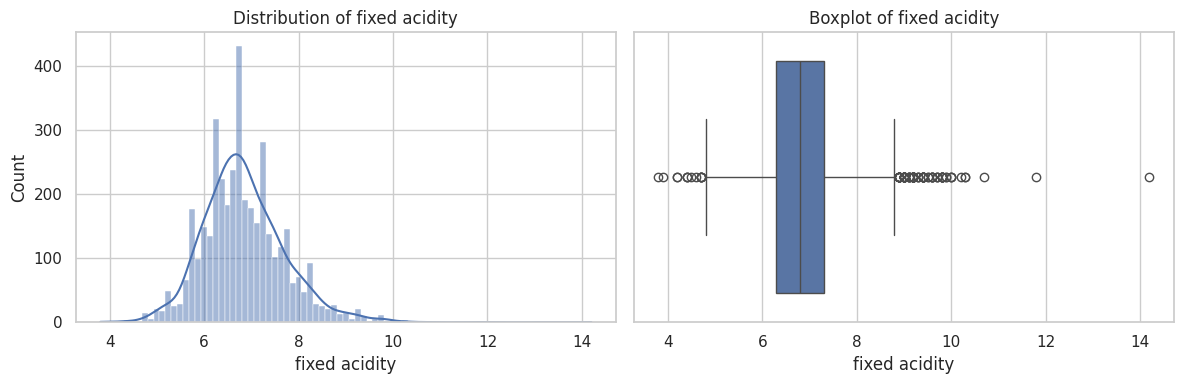

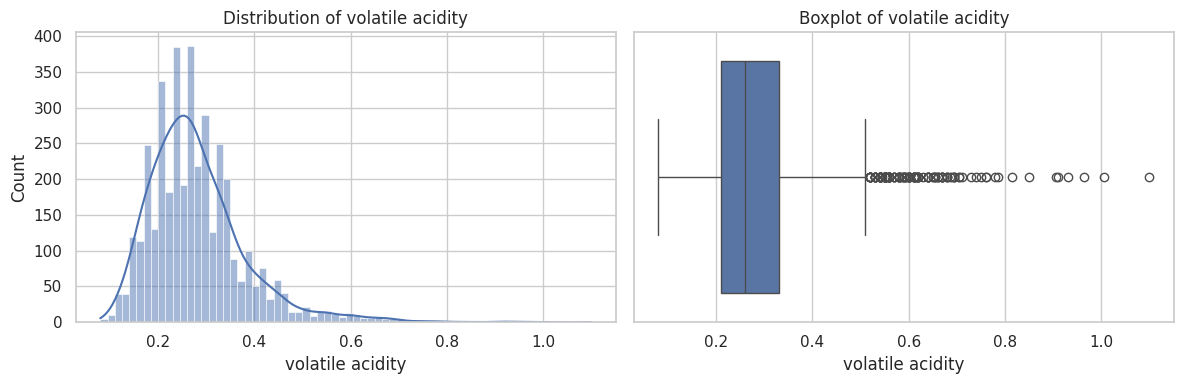

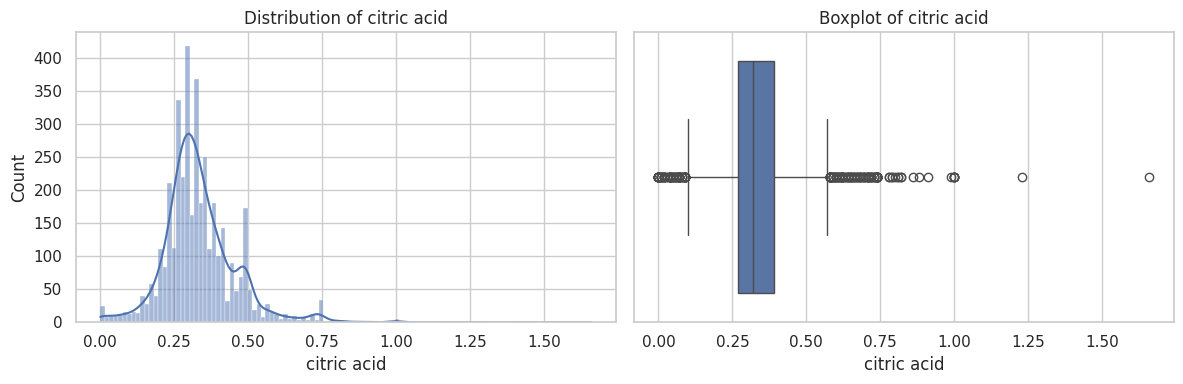

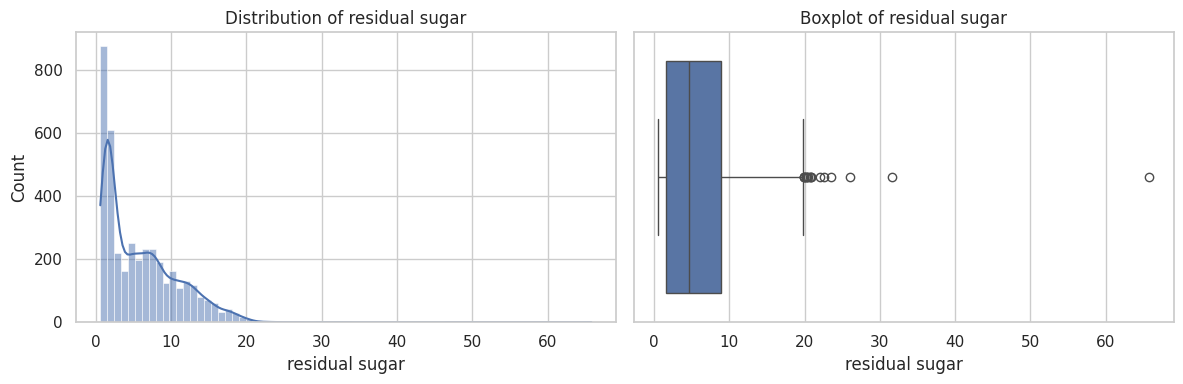

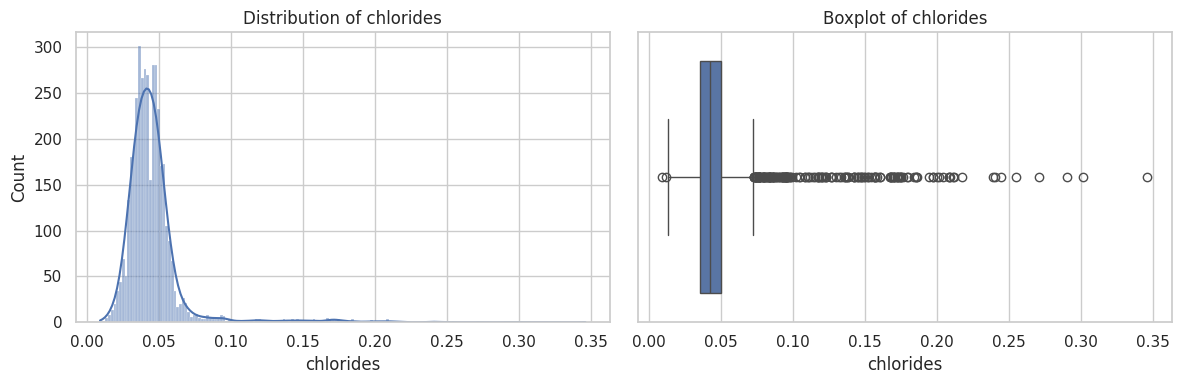

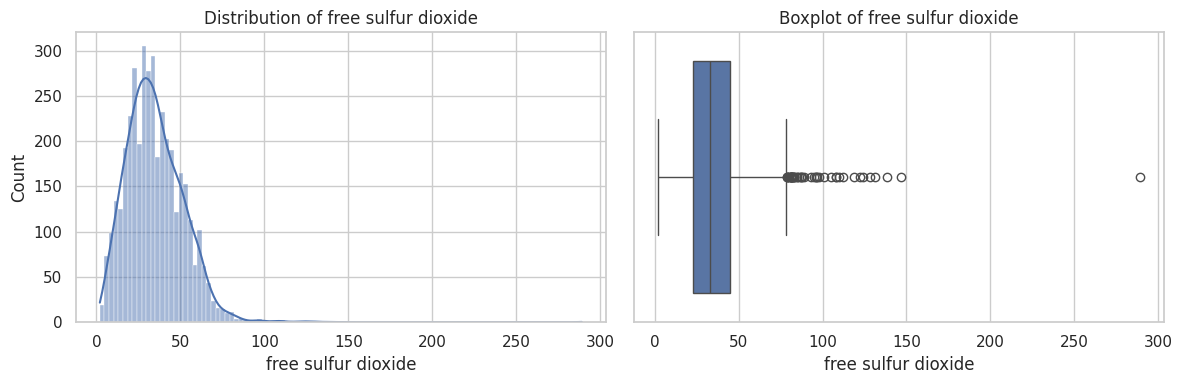

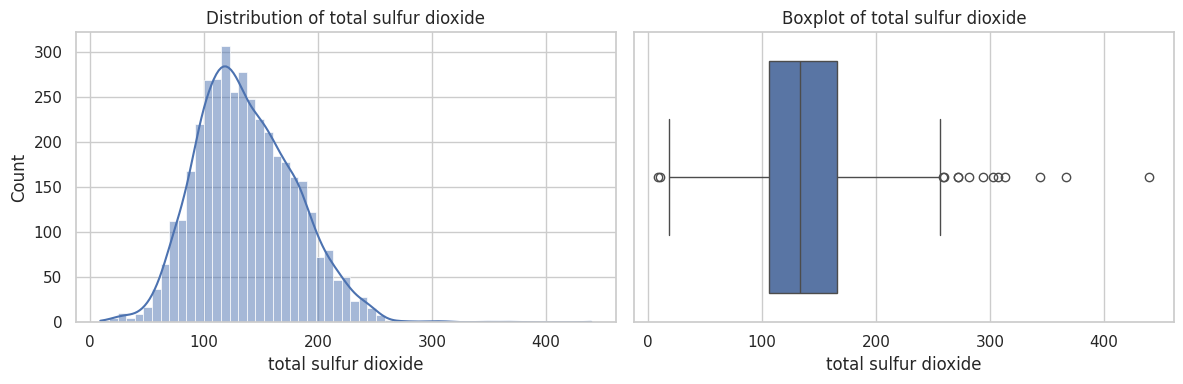

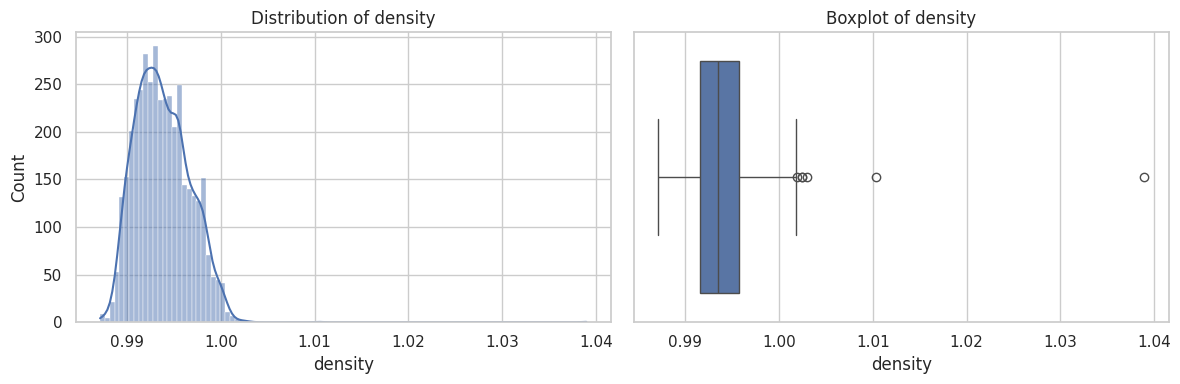

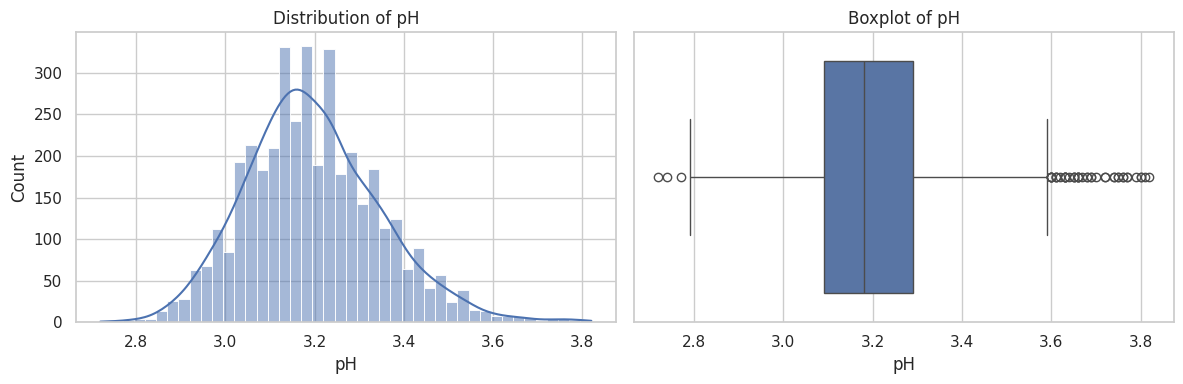

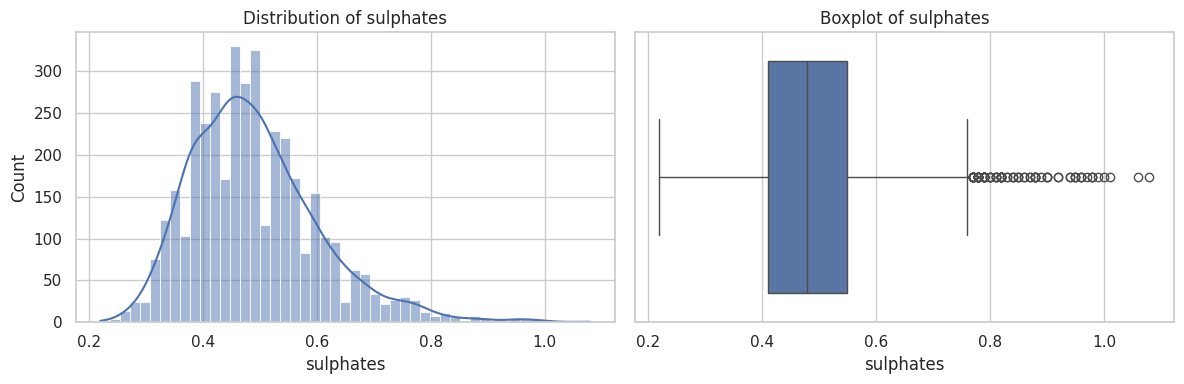

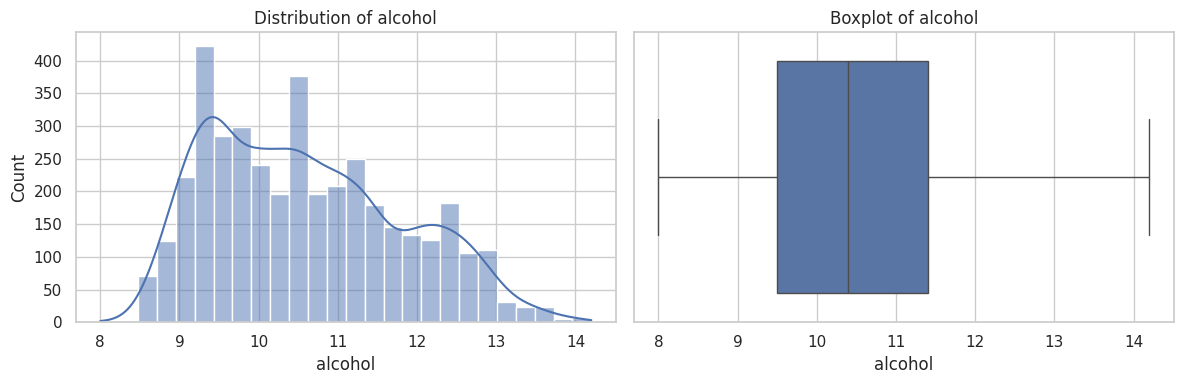

In [ ]:
# Distribution + boxplot for every numerical predictor
for column in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(
        data=raw_wine_df,
        x=column,
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribution of {column}")

    sns.boxplot(
        data=raw_wine_df,
        x=column,
        ax=axes[1]
    )
    axes[1].set_title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()


### Why use both plots?

The histogram/KDE shows the **shape of the distribution**, while the boxplot makes **dispersion and potential extreme values** easier to identify.

Pay special attention to:

- Long right or left tails.
- Multiple modes.
- Variables concentrated in narrow ranges.
- Very large values relative to the bulk of the data.

An extreme value should not automatically be removed. Be aware that domain expertise should be considered before deciding if those extreme values should be filtered or not.


## Potential outliers using the IQR rule

The IQR rule is useful as a diagnostic tool. It flags observations outside:

\[
[Q1 - 1.5 \times IQR,\; Q3 + 1.5 \times IQR]
\]

These observations are **potential outliers**, not necessarily errors.


In [ ]:
outlier_rows = []

for column in numeric_features:
    q1 = raw_wine_df[column].quantile(0.25)
    q3 = raw_wine_df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (raw_wine_df[column] < lower_bound) |
        (raw_wine_df[column] > upper_bound)
    )

    outlier_rows.append({
        "feature": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_potential_outliers": int(mask.sum()),
        "outlier_pct": 100 * mask.mean()
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
      .sort_values("outlier_pct", ascending=False)
)

outlier_summary


,feature,lower_bound,upper_bound,n_potential_outliers,outlier_pct
2,citric acid,0.090000,0.570000,223,5.629891
4,chlorides,0.012500,0.072500,178,4.493815
1,volatile acidity,0.030000,0.510000,133,3.357738
0,fixed acidity,4.800000,8.800000,106,2.676092
9,sulphates,0.200000,0.760000,96,2.423630
8,pH,2.790000,3.590000,46,1.161323
5,free sulfur dioxide,-10.000000,78.000000,44,1.110831
3,residual sugar,-9.350000,19.850000,16,0.403938
6,total sulfur dioxide,16.000000,256.000000,14,0.353446
7,density,0.985485,1.001845,6,0.151477


A feature can show many IQR outliers simply because its natural distribution is strongly skewed. This distinction matters later when deciding whether transformations such as `log1p`, robust scaling, clipping, or no transformation at all are appropriate.

## Bivariate analysis: predictors vs. wine quality

Now analyze how each physicochemical variable changes across values of `quality`.


In [ ]:
# Descriptive statistics of each feature grouped by wine quality
quality_profiles = raw_wine_df.groupby("quality")[numeric_features].agg(
    ["mean", "median", "std"]
)

quality_profiles


fixed acidity                  volatile acidity                   \
                 mean median       std             mean median       std   
quality                                                                    
3            7.600000    7.3  1.724743         0.333250  0.260  0.140827   
4            7.139869    6.9  1.101574         0.382157  0.320  0.176209   
5            6.921745    6.8  0.862071         0.303306  0.285  0.103415   
6            6.819435    6.8  0.853331         0.261630  0.250  0.089767   
7            6.701089    6.7  0.775123         0.265363  0.250  0.092231   
8            6.609924    6.7  0.822646         0.286794  0.280  0.103862   
9            7.420000    7.1  0.983362         0.298000  0.270  0.057619   

        citric acid                  residual sugar  ...   density        pH  \
               mean median       std           mean  ...       std      mean   
quality                                              ...                       
3          0.336000  0.345  0.081460       6.392500  ...  0.002831  3.187500   
4          0.305229  0.300  0.163940       4.499346  ...  0.002474  3.185425   
5          0.335957  0.320  0.140859       6.941532  ...  0.002516  3.171779   
6          0.338227  0.320  0.120617       5.959787  ...  0.002948  3.196029   
7          0.327358  0.320  0.082185       4.523875  ...  0.002427  3.228462   
8          0.335038  0.320  0.087217       5.056489  ...  0.002229  3.235115   
9          0.386000  0.360  0.082037       4.120000  ...  0.003118  3.308000   

                         sulphates                     alcohol         \
        median       std      mean median       std       mean median   
quality                                                                 
3        3.215  0.209834  0.474500   0.44  0.119845  10.345000  10.45   
4        3.160  0.167147  0.476667   0.47  0.119951  10.197712  10.10   
5        3.160  0.143015  0.482621   0.47  0.097936   9.864182   9.60   
6        3.190  0.151125  0.492355   0.48  0.111685  10.646122  10.50   
7        3.220  0.154202  0.502859   0.48  0.131620  11.515844  11.50   
8        3.240  0.150754  0.485878   0.47  0.147965  11.880153  12.20   
9        3.280  0.082885  0.466000   0.46  0.092628  12.180000  12.50   

                   
              std  
quality            
3        1.224089  
4        1.012266  
5        0.864439  
6        1.128400  
7        1.149214  
8        1.058186  
9        1.013410  

[7 rows x 33 columns]

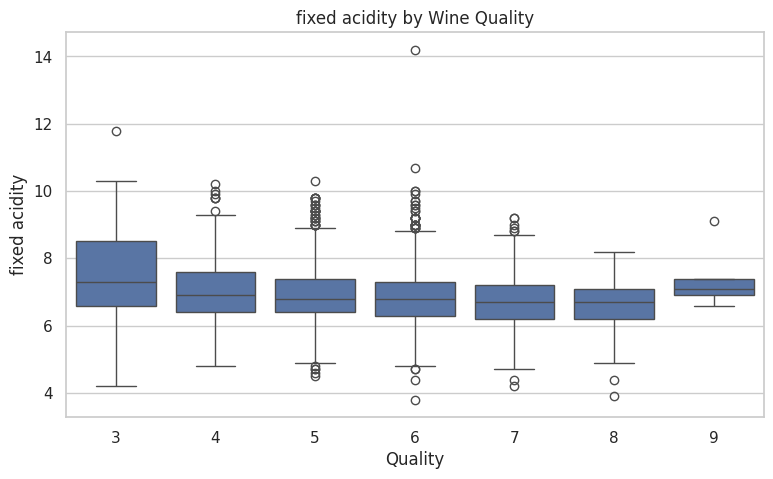

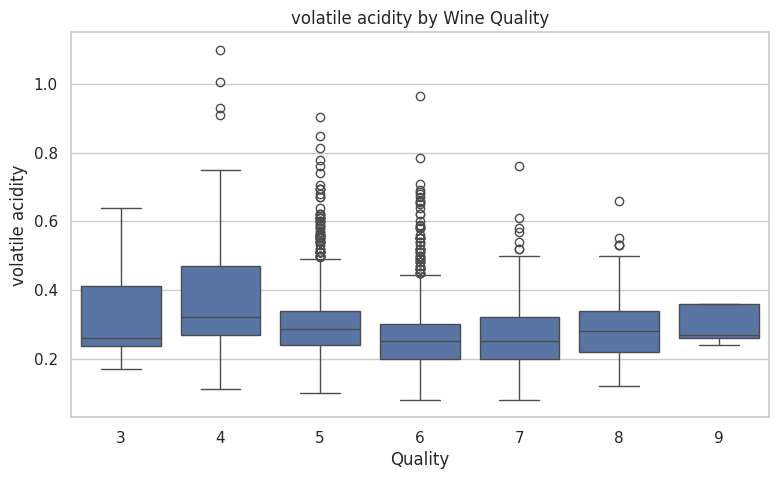

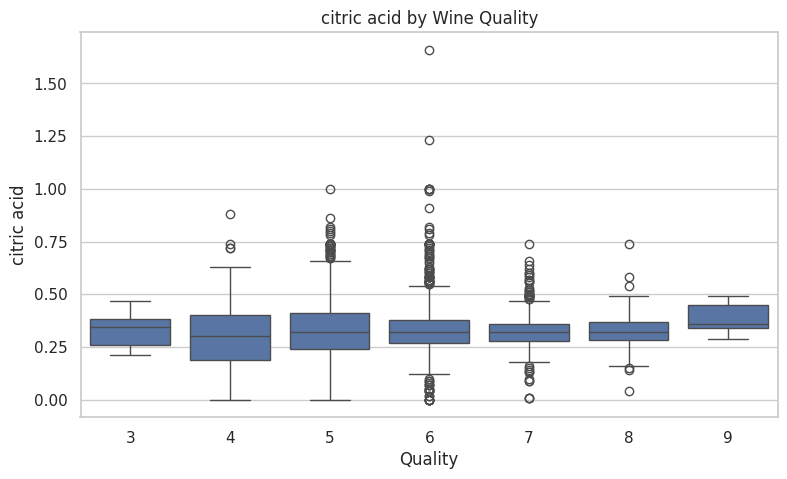

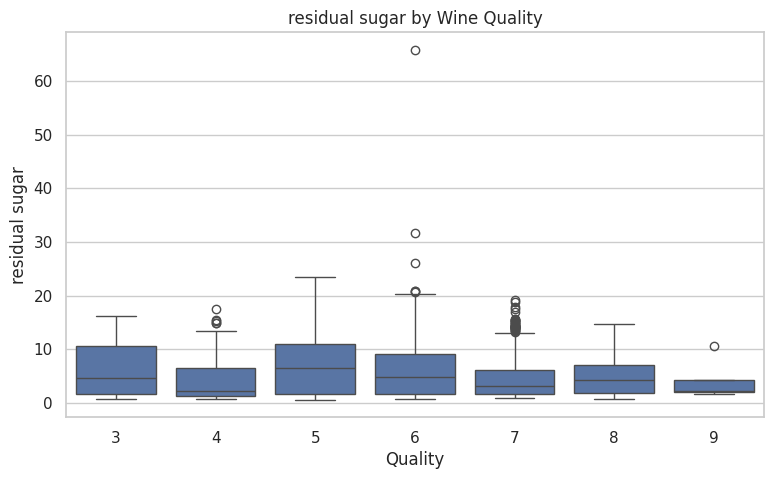

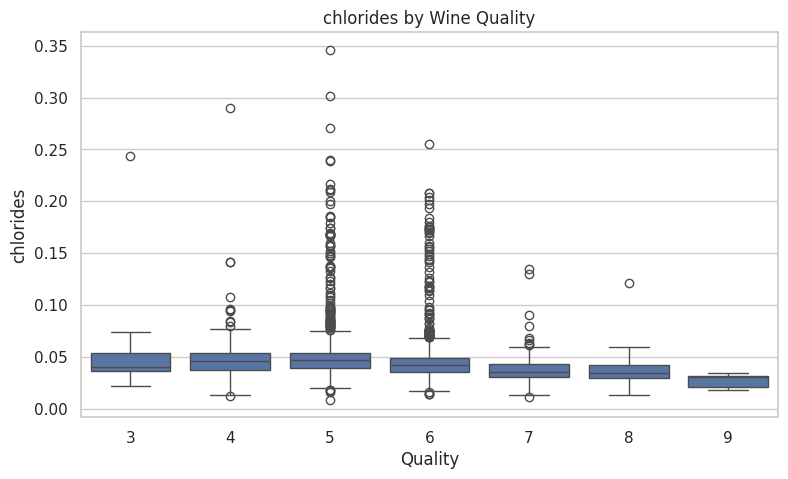

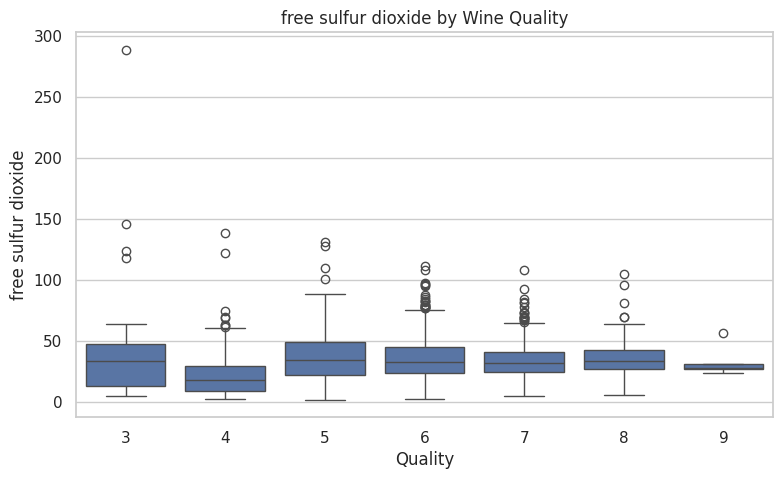

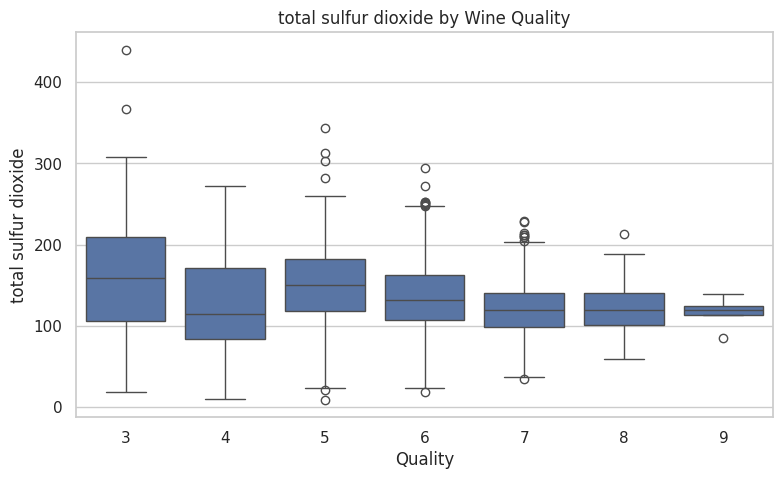

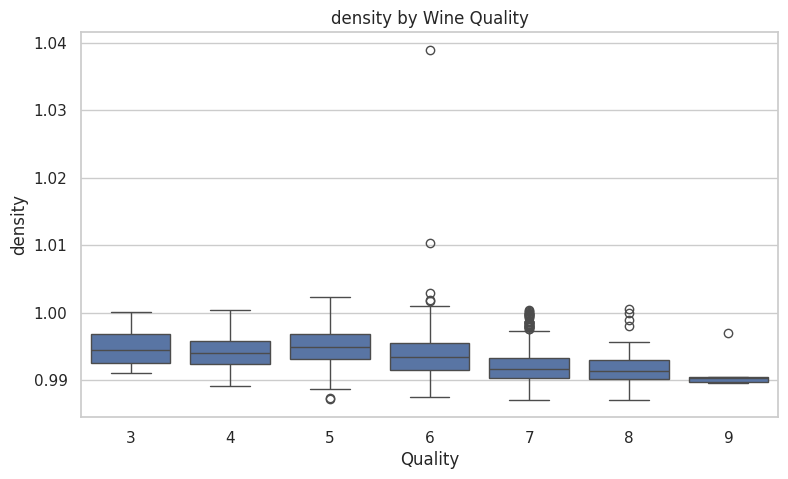

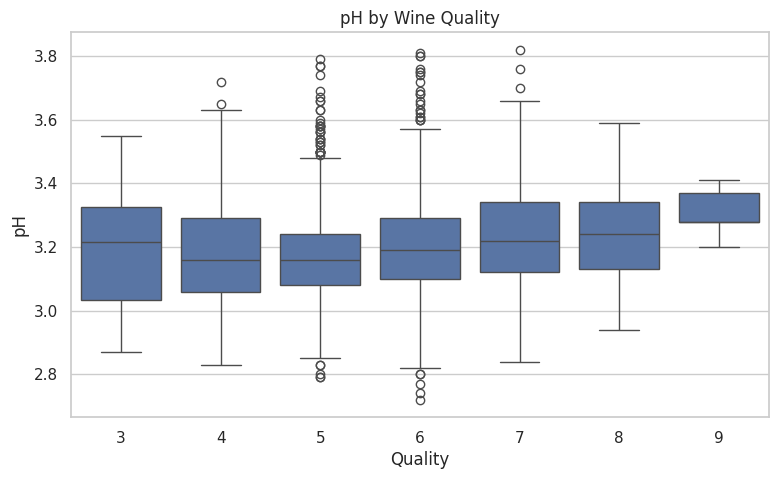

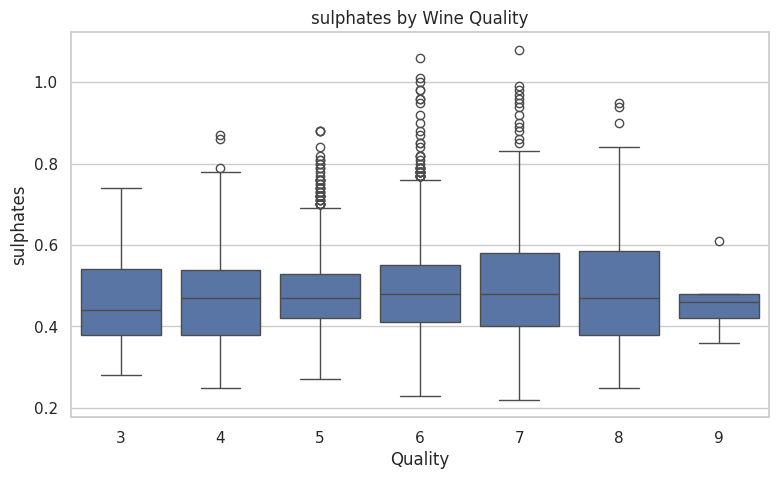

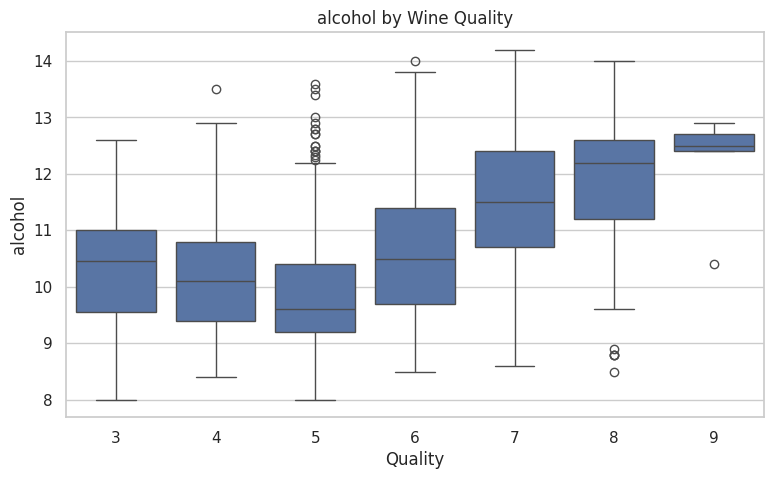

In [ ]:
# Boxplots by quality
for column in numeric_features:
    plt.figure(figsize=(9, 5))
    sns.boxplot(
        data=raw_wine_df,
        x="quality",
        y=column
    )
    plt.title(f"{column} by Wine Quality")
    plt.xlabel("Quality")
    plt.ylabel(column)
    plt.show()


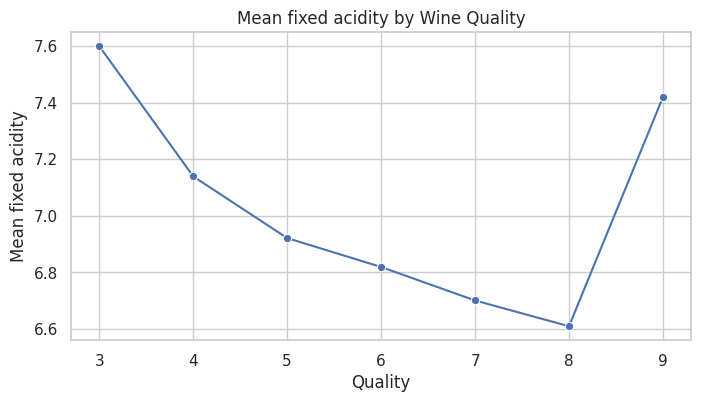

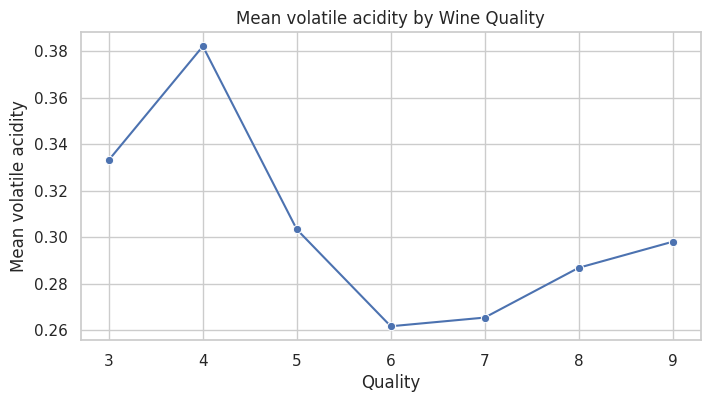

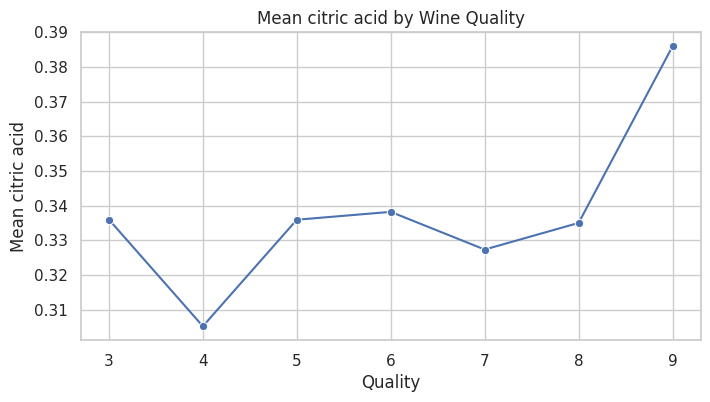

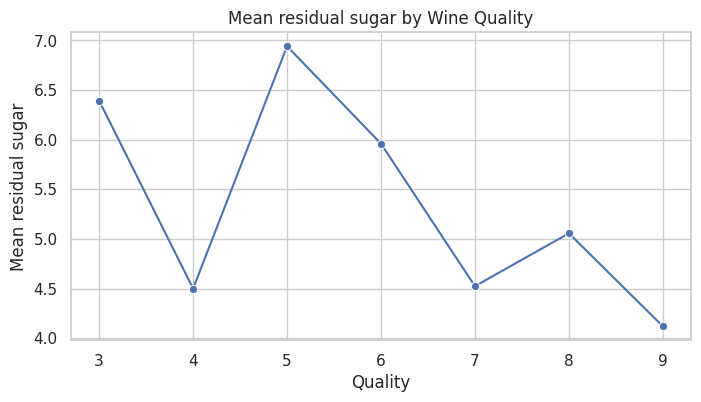

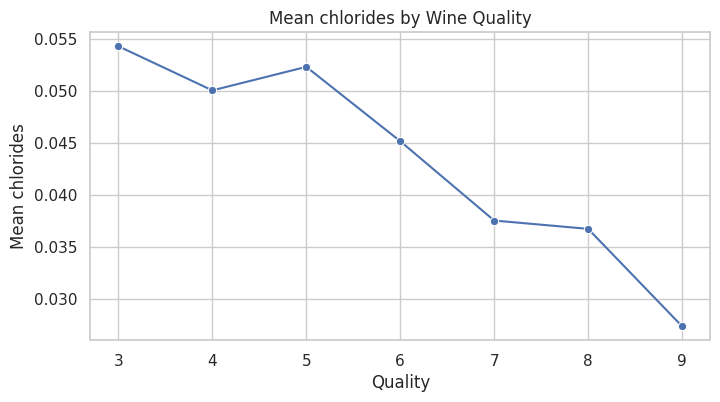

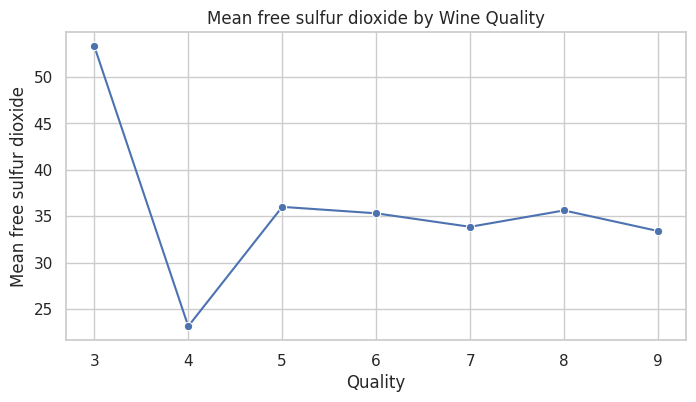

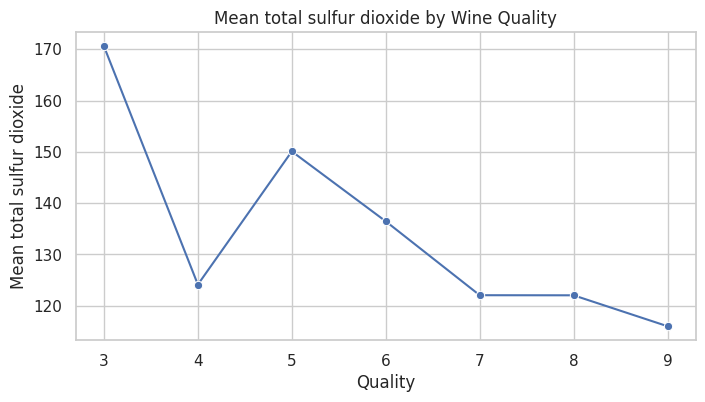

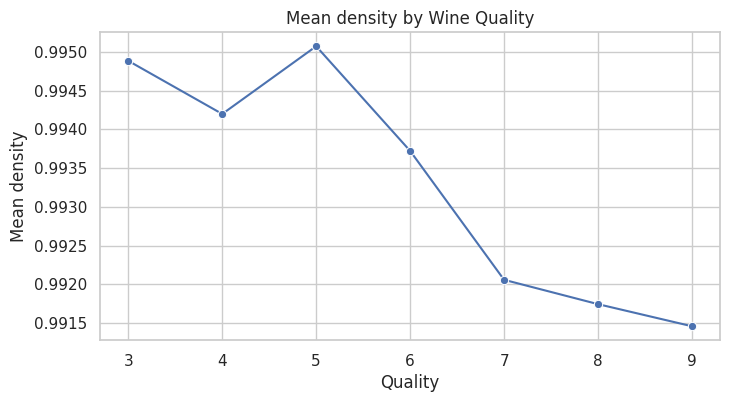

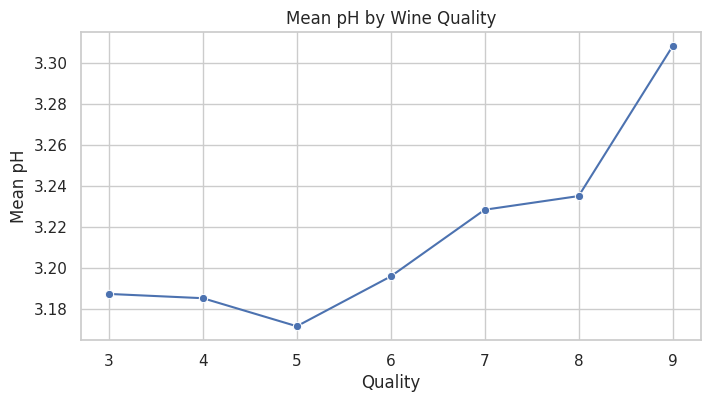

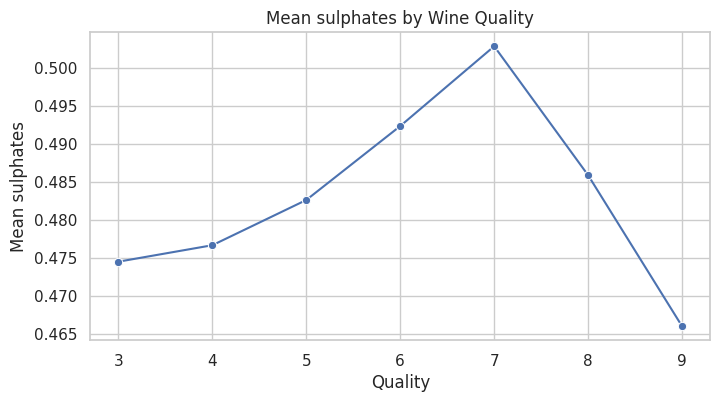

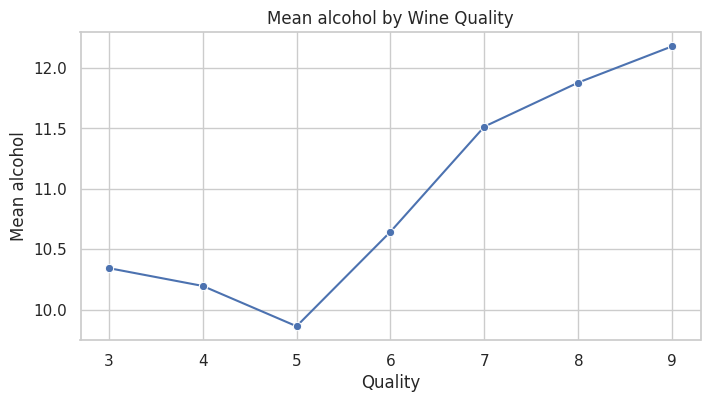

In [ ]:
# Mean feature value by quality.
# This view makes monotonic or non-monotonic trends easier to spot.
for column in numeric_features:
    grouped = (
        raw_wine_df.groupby("quality", as_index=False)[column]
        .mean()
    )

    plt.figure(figsize=(8, 4))
    sns.lineplot(
        data=grouped,
        x="quality",
        y=column,
        marker="o"
    )
    plt.title(f"Mean {column} by Wine Quality")
    plt.xlabel("Quality")
    plt.ylabel(f"Mean {column}")
    plt.show()


## Pairwise relationships among predictors

Strong relationships among predictors may reveal redundant information, common chemical mechanisms, or potential multicollinearity for some model families.


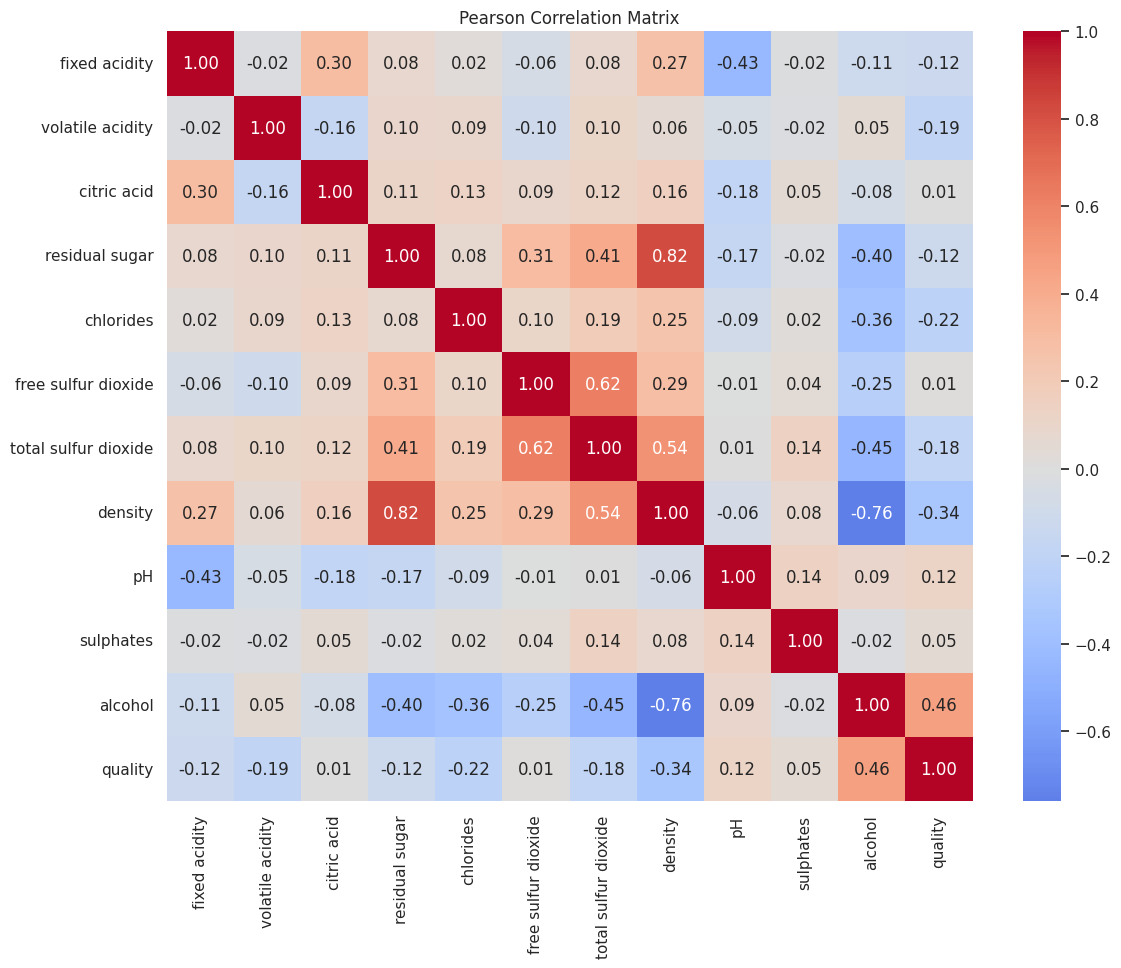

In [ ]:
# Pearson correlation: focuses on linear relationships
pearson_corr = raw_wine_df[numeric_features + ["quality"]].corr(method="pearson")

plt.figure(figsize=(13, 10))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Pearson Correlation Matrix")
plt.show()


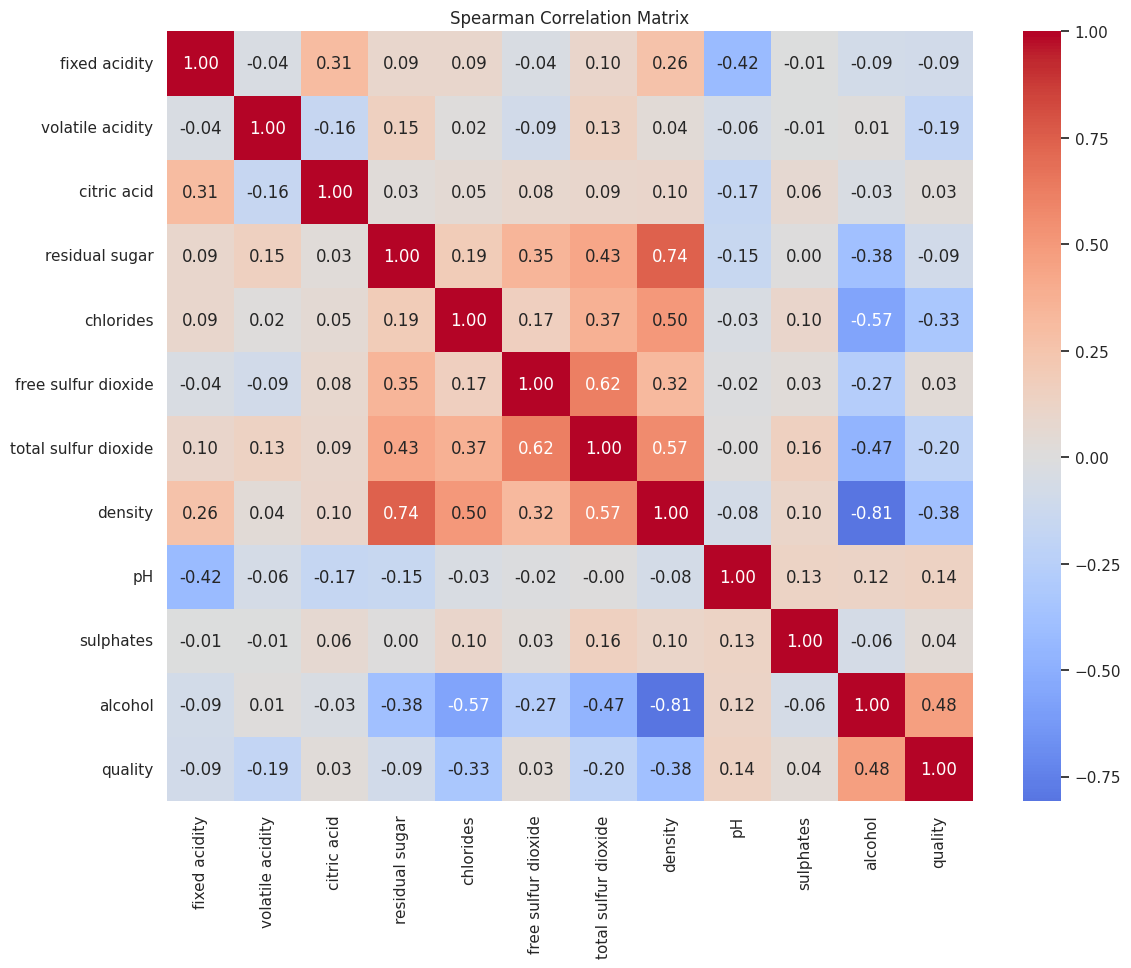

In [ ]:
# Spearman correlation: based on ranks and useful for monotonic,
# potentially non-linear relationships
spearman_corr = raw_wine_df[numeric_features + ["quality"]].corr(method="spearman")

plt.figure(figsize=(13, 10))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Spearman Correlation Matrix")
plt.show()


In [ ]:
# Compare feature correlations with quality under both measures
quality_correlations = pd.DataFrame({
    "pearson_with_quality": pearson_corr["quality"].drop("quality"),
    "spearman_with_quality": spearman_corr["quality"].drop("quality")
})

quality_correlations["abs_pearson"] = (
    quality_correlations["pearson_with_quality"].abs()
)

quality_correlations.sort_values(
    "abs_pearson",
    ascending=False
).drop(columns="abs_pearson")


,pearson_with_quality,spearman_with_quality
alcohol,0.462869,0.475713
density,-0.337805,-0.382900
chlorides,-0.217739,-0.333089
volatile acidity,-0.190678,-0.185385
total sulfur dioxide,-0.183356,-0.202576
fixed acidity,-0.124636,-0.094236
pH,0.123829,0.136190
residual sugar,-0.117339,-0.092462
sulphates,0.053200,0.035592
free sulfur dioxide,0.010507,0.032555


### Pearson vs. Spearman

- **Pearson** measures the strength of a linear relationship.
- **Spearman** measures the strength of a monotonic relationship based on ranks.

If a feature has a noticeably stronger Spearman correlation than Pearson correlation, its relationship with quality may be monotonic but not well represented by a straight line.


## Strongly correlated predictor pairs

Instead of visually scanning the complete correlation matrix, we could extract the pairs with the highest absolute correlations.


In [ ]:
feature_corr = raw_wine_df[numeric_features].corr()

upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

strong_pairs = (
    upper_triangle.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2"
    })
)

strong_pairs["abs_correlation"] = strong_pairs["correlation"].abs()

strong_pairs.sort_values(
    "abs_correlation",
    ascending=False
).head(15)


,feature_1,feature_2,correlation,abs_correlation
30,residual sugar,density,0.820498,0.820498
51,density,alcohol,-0.760162,0.760162
40,free sulfur dioxide,total sulfur dioxide,0.619437,0.619437
45,total sulfur dioxide,density,0.536868,0.536868
48,total sulfur dioxide,alcohol,-0.446643,0.446643
7,fixed acidity,pH,-0.431274,0.431274
29,residual sugar,total sulfur dioxide,0.409583,0.409583
33,residual sugar,alcohol,-0.398167,0.398167
39,chlorides,alcohol,-0.356928,0.356928
28,residual sugar,free sulfur dioxide,0.306835,0.306835


## Focused pairwise visualization

A full pairplot with every feature can become difficult to read. Instead, select the features with the strongest absolute association with `quality` and inspect them jointly.


Features selected for focused pairplot: ['alcohol', 'density', 'chlorides', 'volatile acidity']


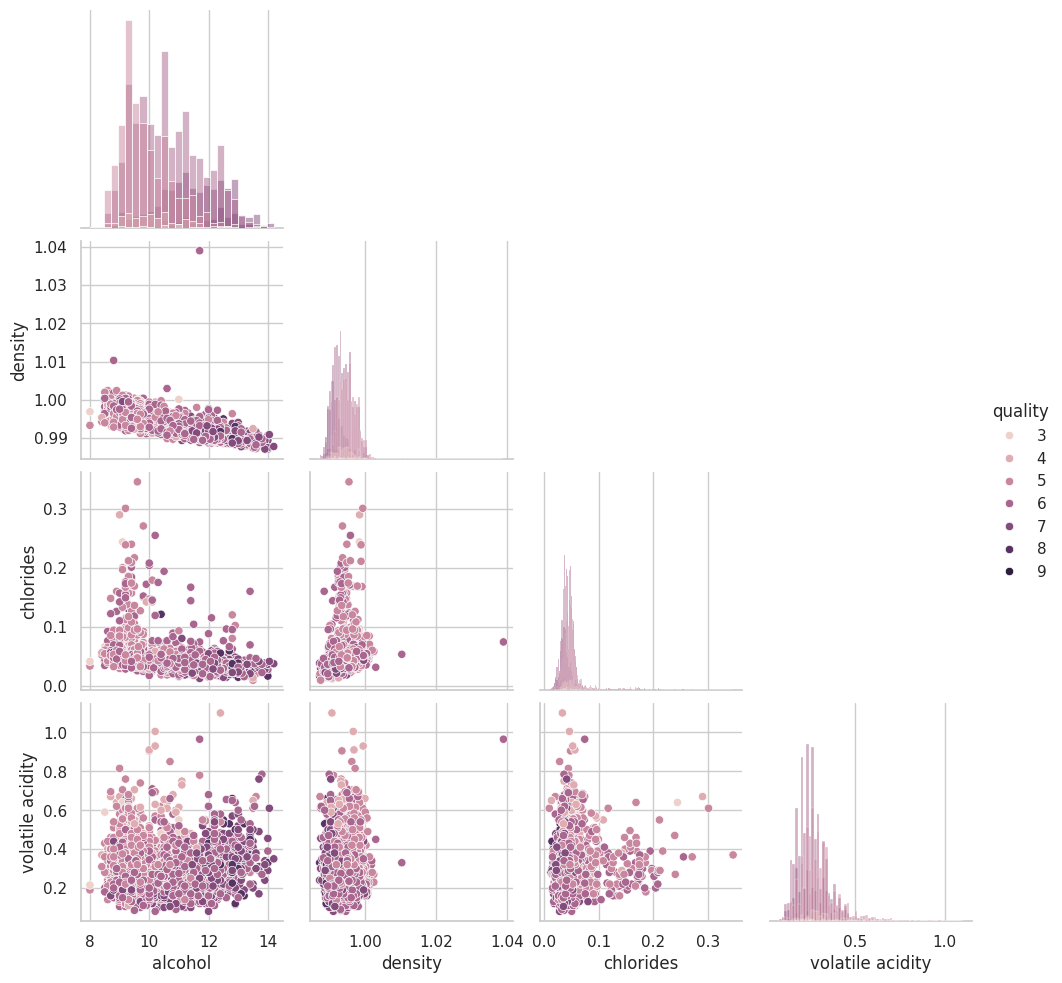

In [ ]:
top_features = (
    quality_correlations["pearson_with_quality"]
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

print("Features selected for focused pairplot:", top_features)

sns.pairplot(
    raw_wine_df[top_features + ["quality"]],
    hue="quality",
    corner=True,
    diag_kind="hist"
)

plt.show()


## Standardized multivariate profile by quality

Features are measured on very different scales. Standardizing the group means only for visualization makes it easier to compare how the typical feature changes across quality levels.

This transformation is exploratory and does not modify the raw dataset.


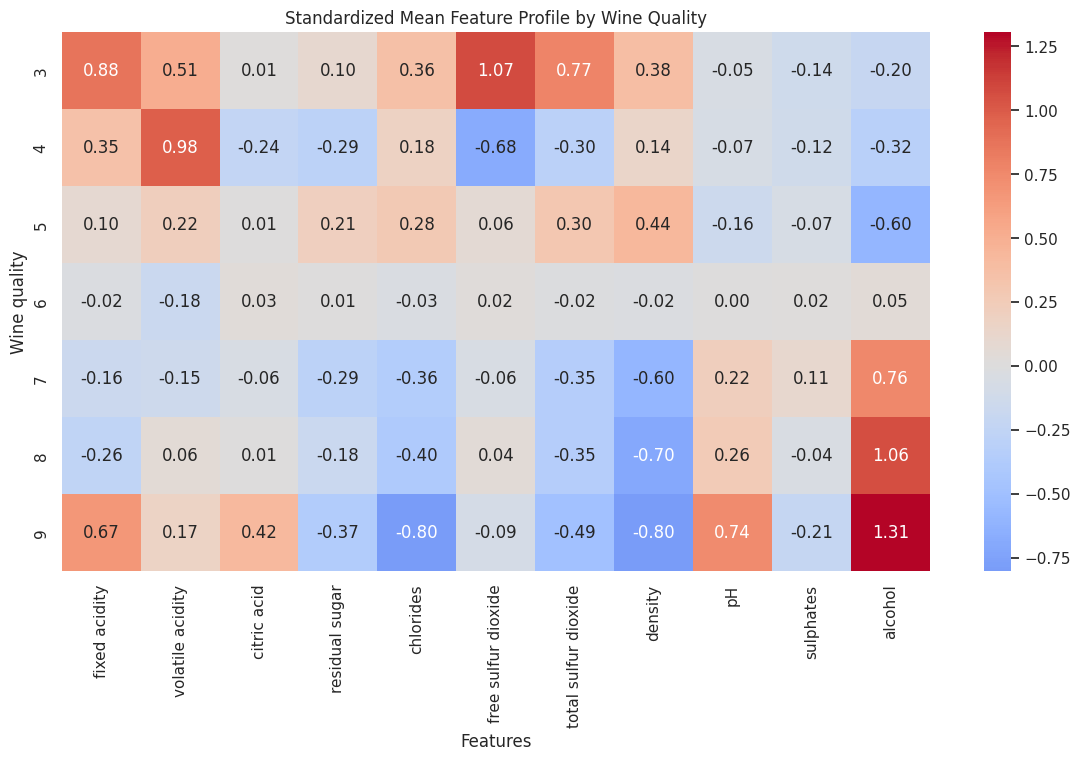

In [ ]:
feature_means_by_quality = (
    raw_wine_df.groupby("quality")[numeric_features]
    .mean()
)

standardized_profiles = (
    feature_means_by_quality - raw_wine_df[numeric_features].mean()
) / raw_wine_df[numeric_features].std()

plt.figure(figsize=(14, 7))
sns.heatmap(
    standardized_profiles,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Standardized Mean Feature Profile by Wine Quality")
plt.xlabel("Features")
plt.ylabel("Wine quality")
plt.show()


Each value indicates how far the **mean for a quality group** is from the overall feature mean, measured in standard deviations.

- Positive values: above the dataset-wide mean.
- Negative values: below the dataset-wide mean.
- Values near zero: close to the overall mean.


>The purpose of EDA is not to justify a model that has already been selected. It is to identify properties of the data that should inform subsequent decisions.


## Next step: comparison in notebook 1.4

Notebook `1.4_WineQuality_DataCleaning.ipynb` cleans the perturbed file `modified.csv` with two strategies (dropping invalid
rows, and filling invalid values with an estimate), removes duplicates in both, and compares the results against
`original_no_duplicates.csv` generated here. The EDA results of this notebook are the reference for that comparison:

1. **Target distribution.** The class proportions of `quality`.
2. **Univariate summary.** Means, medians and spread; skewness and kurtosis are more sensitive, because they depend on a
   handful of extreme but valid wines.
3. **IQR outliers.** The share of *potential* outliers created by the natural tails of skewed variables.
4. **Correlations with quality.** Which features (e.g. alcohol, density, chlorides) are most associated with quality.
5. **Standardized profiles by quality.** How the typical wine changes across quality levels.